In [1]:
# ================================
# DATA GENERATION USING SIMULATION
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import warnings
warnings.filterwarnings("ignore")

# ---------------------------
# PARAMETER BOUNDS
# ---------------------------

PARAM_BOUNDS = {
    "n_samples": (100, 2000),
    "n_features": (5, 50),
    "noise": (0, 50)
}

# ---------------------------
# GENERATE 1000 SIMULATIONS
# ---------------------------

datasets = []

for i in range(1000):
    n_samples = np.random.randint(*PARAM_BOUNDS["n_samples"])
    n_features = np.random.randint(*PARAM_BOUNDS["n_features"])
    noise = np.random.uniform(*PARAM_BOUNDS["noise"])

    X, y = make_regression(
        n_samples=n_samples,
        n_features=n_features,
        noise=noise,
        random_state=i
    )

    datasets.append((X, y))

print("Total Simulated Datasets:", len(datasets))

# ---------------------------
# USE ONE DATASET FOR ML TRAINING
# ---------------------------

X, y = datasets[0]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# ML MODELS
# ---------------------------

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2 Score"])
results_df = results_df.sort_values(by="RMSE")

results_df


Total Simulated Datasets: 1000


,Model,RMSE,R2 Score
1,Ridge Regression,4.434620,0.999650
0,Linear Regression,4.478260,0.999643
2,Lasso Regression,5.521023,0.999458
5,Gradient Boosting,83.301166,0.876619
4,Random Forest,122.461511,0.733347
7,KNN,126.499382,0.715473
3,Decision Tree,193.274809,0.335802
6,SVR,224.197846,0.106263


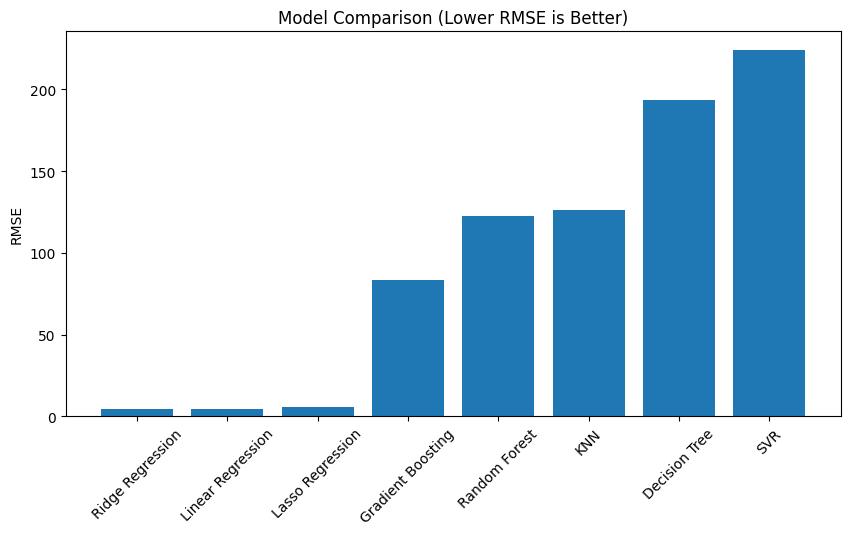

In [2]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Model Comparison (Lower RMSE is Better)")
plt.show()
